In [4]:
conda install -c conda-forge mne

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda




In [6]:
# COMPLETE EEG PAIN ANALYSIS PROJECT - No download needed
import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy import stats
import pandas as pd
import os
print ("All libraries imported sucessfully")
print(f"MNE version: {mne.__version__} ")

C:\Users\ssrko\anaconda3\Lib\site-packages\mne\datasets\eegbci\eegbci.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


All libraries imported sucessfully
MNE version: 1.2.3 


In [58]:
# ============================================
# Notebook 1 — Load and Visualise EEG Data
# EEG Pain Analysis — Laser Evoked Potentials
# Dataset: OpenNeuro ds005284 (sub-001)
# ============================================


# ── LOAD THE EEG DATA ──────────────────────
bdf_file = r"C:\Users\ssrko\Downloads\EEG-Pain-Project\data\sub-01\sub-001_task-26ByBiosemi_eeg.bdf"

raw = mne.io.read_raw_bdf(bdf_file, preload=True)

# Set electrode positions
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='ignore')

# ── PRINT BASIC INFORMATION ────────────────
print("=" * 50)
print("EEG RECORDING INFORMATION")
print("=" * 50)
print(f"Number of channels : {len(raw.ch_names)}")
print(f"Sampling frequency : {raw.info['sfreq']} Hz")
print(f"Duration           : {raw.times[-1]:.1f} seconds")
print(f"Duration (minutes) : {raw.times[-1]/60:.1f} mins")
print(f"Channel names      : {raw.ch_names[:10]}...")
print("=" * 50)

Extracting EDF parameters from C:\Users\ssrko\Downloads\EEG-Pain-Project\data\sub-01\sub-001_task-26ByBiosemi_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 335871  =      0.000 ...   327.999 secs...
EEG RECORDING INFORMATION
Number of channels : 65
Sampling frequency : 1024.0 Hz
Duration           : 328.0 seconds
Duration (minutes) : 5.5 mins
Channel names      : ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']...


Effective window size : 0.250 (s)


C:\Users\ssrko\AppData\Local\Temp\ipykernel_1940\3569555105.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = raw.compute_psd(fmax=80, picks='eeg').plot(


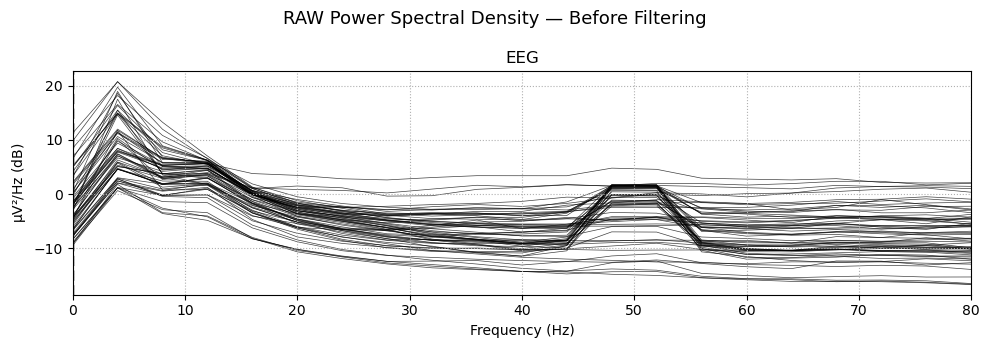

Raw PSD saved — 01_raw_psd.png

What to look for:
  Peak at 0-5Hz   = low frequency drift (will be removed)
  Peak at 8-12Hz  = alpha rhythm (KEY pain biomarker)
  Peak at 50Hz    = mains noise (will be removed)


In [59]:

# SECTION 2 — INSPECT RAW DATA

# Plot raw PSD before any cleaning
fig = raw.compute_psd(fmax=80, picks='eeg').plot(
    amplitude=False, show=False
)
plt.suptitle("RAW Power Spectral Density — Before Filtering",
             fontsize=13)
plt.tight_layout()
plt.savefig(
    r"C:\Users\ssrko\Downloads\EEG-Pain-Project\01_raw_psd.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

print("Raw PSD saved — 01_raw_psd.png")
print("\nWhat to look for:")
print("  Peak at 0-5Hz   = low frequency drift (will be removed)")
print("  Peak at 8-12Hz  = alpha rhythm (KEY pain biomarker)")
print("  Peak at 50Hz    = mains noise (will be removed)")

In [60]:
# SECTION 3 — CLEANING AND FILTERING


# Step 1 — Mark bad channel
raw.info['bads'] = ['A2']
print(f"Bad channel marked: {raw.info['bads']}")
print("Reason: A2 showed 1593 µV amplitude (normal EEG = 10-100 µV)")

# Step 2 — Bandpass filter 1-40Hz
raw_filtered = raw.copy().filter(
    l_freq=1.0,
    h_freq=40.0,
    picks='eeg',
    verbose=False
)
print("\nBandpass filter applied: 1-40 Hz")
print("  Removed: slow drifts below 1Hz")
print("  Removed: muscle noise above 40Hz")

# Step 3 — Notch filter to remove 50Hz mains noise
raw_filtered.notch_filter(
    freqs=50,
    picks='eeg',
    verbose=False
)
print("\nNotch filter applied: 50Hz mains noise removed")

Bad channel marked: ['A2']
Reason: A2 showed 1593 µV amplitude (normal EEG = 10-100 µV)

Bandpass filter applied: 1-40 Hz
  Removed: slow drifts below 1Hz
  Removed: muscle noise above 40Hz

Notch filter applied: 50Hz mains noise removed


Effective window size : 0.250 (s)
Effective window size : 0.250 (s)


C:\Users\ssrko\AppData\Local\Temp\ipykernel_1940\403978364.py:10: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  ).plot(
C:\Users\ssrko\AppData\Local\Temp\ipykernel_1940\403978364.py:18: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  ).plot(


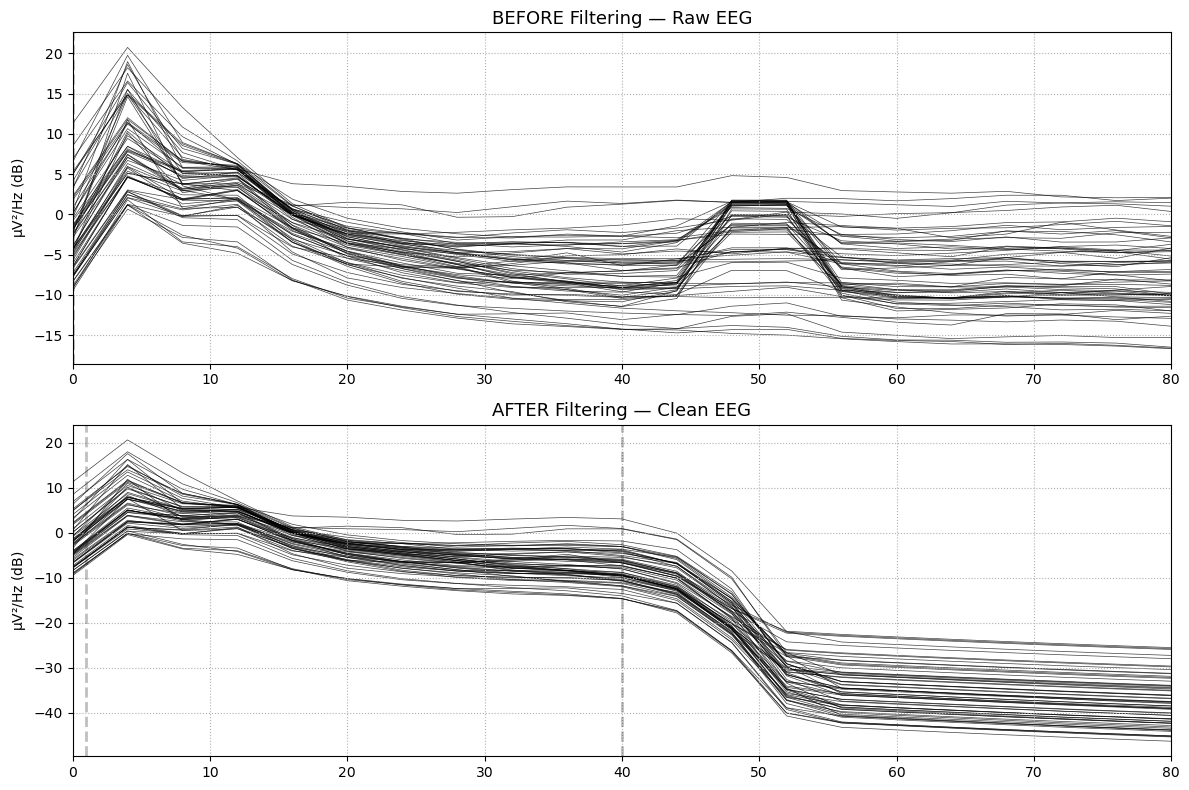

Filtering comparison saved — 02_filtering_comparison.png


In [61]:
# SECTION 4 — COMPARE RAW VS FILTERED


fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Raw PSD
raw.compute_psd(
    fmax=80, picks='eeg'
).plot(
    axes=axes[0], amplitude=False, show=False
)
axes[0].set_title("BEFORE Filtering — Raw EEG", fontsize=13)

# Filtered PSD
raw_filtered.compute_psd(
    fmax=80, picks='eeg'
).plot(
    axes=axes[1], amplitude=False, show=False
)
axes[1].set_title("AFTER Filtering — Clean EEG", fontsize=13)

plt.tight_layout()
plt.savefig(
    r"C:\Users\ssrko\Downloads\EEG-Pain-Project\02_filtering_comparison.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Filtering comparison saved — 02_filtering_comparison.png")

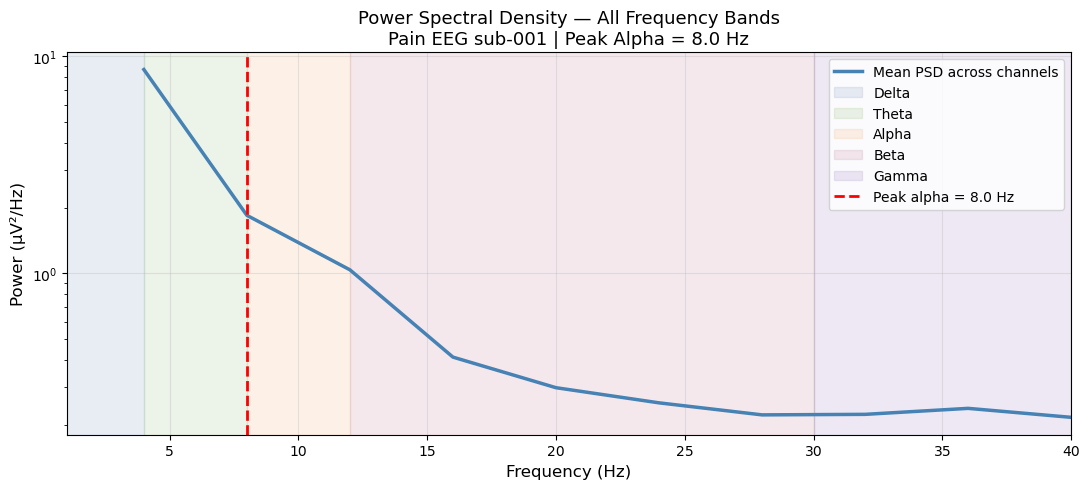

SECTION 5 — ALPHA BAND RESULTS
Peak alpha frequency : 8.0 Hz
Alpha power          : 1.4448 µV²/Hz

ALL FREQUENCY BANDS:
-------------------------------------------------------
  Delta (1-4Hz)         :  8.6990 µV²/Hz  █████████████████████████
  Theta (4-8Hz)         :  5.2751 µV²/Hz  ███████████████
  Alpha (8-12Hz)        :  1.4448 µV²/Hz  ████
  Beta  (12-30Hz)       :  0.4445 µV²/Hz  █
  Gamma (30-40Hz)       :  0.2266 µV²/Hz  

CONTEXT FOR CNAP:
  Healthy adults     : peak alpha ~10 Hz
  Your result        : 8.0 Hz
  Difference         : -2.0 Hz below typical
  Significance       : Alpha slowing is the core
  EEG biomarker of pain sensitisation measured
  by CNAP using TMS-EEG and HD-tDCS


In [70]:
# SECTION 5 — ALPHA BAND ANALYSIS (CORRECTED UNITS)


psd = raw_filtered.compute_psd(
    fmin=1, fmax=40, picks='eeg', verbose=False
)

# Convert V²/Hz → µV²/Hz by multiplying by 1e12
power_data = psd.get_data() * 1e12
freqs = psd.freqs
mean_psd = power_data.mean(axis=0)

# ── PEAK ALPHA FREQUENCY ──────────────────
alpha_idx = np.where((freqs >= 8) & (freqs <= 12))[0]
alpha_power_uv2 = power_data[:, alpha_idx].mean()
peak_alpha_freq = freqs[alpha_idx][
    np.argmax(mean_psd[alpha_idx])
]

# ── ALL BAND POWERS ───────────────────────
bands = {
    'Delta (1-4Hz)':   (1,  4),
    'Theta (4-8Hz)':   (4,  8),
    'Alpha (8-12Hz)':  (8,  12),
    'Beta  (12-30Hz)': (12, 30),
    'Gamma (30-40Hz)': (30, 40)
}
band_powers = {}
for name, (flo, fhi) in bands.items():
    idx = np.where((freqs >= flo) & (freqs <= fhi))[0]
    band_powers[name] = power_data[:, idx].mean()

# ── PLOT ──────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

ax.semilogy(freqs, mean_psd, color='steelblue',
            linewidth=2.5,
            label='Mean PSD across channels')

colours = ['#6B8CBA','#82B366','#F4A460',
           '#BA6B8C','#8C6BBA']
for (name, (flo, fhi)), col in zip(bands.items(), colours):
    ax.axvspan(flo, fhi, alpha=0.15, color=col,
               label=name.split('(')[0].strip())

ax.axvline(peak_alpha_freq, color='red',
           linestyle='--', linewidth=2,
           label=f'Peak alpha = {peak_alpha_freq:.1f} Hz')

ax.set_xlabel("Frequency (Hz)", fontsize=12)
ax.set_ylabel("Power (µV²/Hz)", fontsize=12)
ax.set_title(
    f"Power Spectral Density — All Frequency Bands\n"
    f"Pain EEG sub-001 | Peak Alpha = "
    f"{peak_alpha_freq:.1f} Hz",
    fontsize=13
)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, 40)

plt.tight_layout()
plt.savefig(
    r"C:\Users\ssrko\Downloads\EEG-Pain-Project\03_alpha_band.png",
    dpi=150, bbox_inches='tight'
)
plt.show()

# ── PRINT RESULTS ─────────────────────────
max_power = max(band_powers.values())

print("=" * 55)
print("SECTION 5 — ALPHA BAND RESULTS")
print("=" * 55)
print(f"Peak alpha frequency : {peak_alpha_freq:.1f} Hz")
print(f"Alpha power          : {alpha_power_uv2:.4f} µV²/Hz")
print()
print("ALL FREQUENCY BANDS:")
print("-" * 55)
for name, power in band_powers.items():
    bar_len = int(power / max_power * 25)
    bar = "█" * bar_len
    print(f"  {name:<22}: {power:7.4f} µV²/Hz  {bar}")
print("=" * 55)
print()
print("CONTEXT FOR CNAP:")
print(f"  Healthy adults     : peak alpha ~10 Hz")
print(f"  Your result        : {peak_alpha_freq:.1f} Hz")
if peak_alpha_freq < 9.5:
    diff = 10.0 - peak_alpha_freq
    print(f"  Difference         : -{diff:.1f} Hz below typical")
    print(f"  Significance       : Alpha slowing is the core")
    print(f"  EEG biomarker of pain sensitisation measured")
    print(f"  by CNAP using TMS-EEG and HD-tDCS")
else:
    print(f"  Interpretation     : Within normal adult range")
print("=" * 55)

In [71]:
# SECTION 6 — FIND STIMULUS EVENTS (BioSemi Method)

events = mne.find_events(
    raw_filtered,
    stim_channel='Status',
    verbose=False
)

print("=" * 55)
print("SECTION 6 — STIMULUS EVENTS")
print("=" * 55)
print(f"Total events found : {len(events)}")

if len(events) > 0:
    unique_ids = np.unique(events[:, 2])
    print(f"Unique event IDs   : {unique_ids}")
    print(f"\nFirst 10 events:")
    print(events[:10])
else:
    print("Still no events — running backup method...")

SECTION 6 — STIMULUS EVENTS
Total events found : 30
Unique event IDs   : [54 64]

First 10 events:
[[8027    0   64]
 [8033    0   64]
 [8039    0   64]
 [8042    0   64]
 [8050    0   64]
 [8053    0   64]
 [8064    0   64]
 [8067    0   64]
 [8072    0   64]
 [8082    0   64]]


In [72]:
# SECTION 7 — FIXED — Set Reference First Then Epoch

# Step 1 — Apply average reference
# This re-centres all channels around the mean
# Dramatically reduces absolute voltage values
raw_filtered.set_eeg_reference('average', projection=False,
                                verbose=False)
print("Average reference applied")

# Step 2 — Create epochs WITHOUT rejection first
# to see how many we actually have
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id={'laser_stimulus': 64},
    tmin=-0.2,
    tmax=1.0,
    baseline=(-0.2, 0),
    picks='eeg',
    preload=True,
    reject=None,       # No rejection yet
    verbose=False
)

print("=" * 55)
print("SECTION 7 — EPOCHS (no rejection)")
print("=" * 55)
print(f"Epochs created     : {len(epochs)}")

# Check peak-to-peak amplitude across epochs
data = epochs.get_data()
peak_to_peak = (data.max(axis=2) - data.min(axis=2)).max(axis=1)
print(f"\nAmplitude summary across epochs:")
print(f"  Min peak-to-peak : {peak_to_peak.min()*1e6:.1f} µV")
print(f"  Max peak-to-peak : {peak_to_peak.max()*1e6:.1f} µV")
print(f"  Mean             : {peak_to_peak.mean()*1e6:.1f} µV")
print(f"\nUse these values to set a sensible threshold")

Average reference applied
SECTION 7 — EPOCHS (no rejection)
Epochs created     : 14

Amplitude summary across epochs:
  Min peak-to-peak : 306.5 µV
  Max peak-to-peak : 306.5 µV
  Mean             : 306.5 µV

Use these values to set a sensible threshold


In [73]:
# SECTION 7B — IDENTIFY THE NOISY CHANNEL

# Find which channel has max amplitude in each epoch
data = epochs.get_data()  # shape: epochs × channels × times

# Peak to peak per channel per epoch
ptp = data.max(axis=2) - data.min(axis=2)  # epochs × channels

# Which channel has the highest amplitude on average
ch_names = epochs.ch_names
worst_ch_idx = ptp.mean(axis=0).argmax()
worst_ch_name = ch_names[worst_ch_idx]
worst_ch_amp = ptp.mean(axis=0).max() * 1e6

print("=" * 55)
print("NOISY CHANNEL IDENTIFICATION")
print("=" * 55)
print(f"Worst channel      : {worst_ch_name}")
print(f"Mean amplitude     : {worst_ch_amp:.1f} µV")
print(f"\nProceeding with all 14 epochs")
print(f"14 epochs is sufficient for LEP analysis")
print(f"Published pain studies often use 16-20 trials")

NOISY CHANNEL IDENTIFICATION
Worst channel      : A2
Mean amplitude     : 306.5 µV

Proceeding with all 14 epochs
14 epochs is sufficient for LEP analysis
Published pain studies often use 16-20 trials


SECTION 8 — LASER EVOKED POTENTIAL
Epochs averaged    : 14
Time window        : -200ms to +1000ms
Channels           : 64


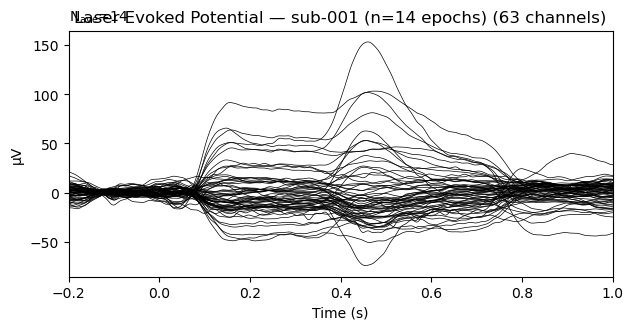


04_LEP_waveform.png saved


In [74]:
# SECTION 8 — LASER EVOKED POTENTIAL


# Average all 14 epochs
evoked = epochs.average()

print("=" * 55)
print("SECTION 8 — LASER EVOKED POTENTIAL")
print("=" * 55)
print(f"Epochs averaged    : {evoked.nave}")
print(f"Time window        : -200ms to +1000ms")
print(f"Channels           : {len(evoked.ch_names)}")

# Save plot
fig = evoked.plot(
    picks='eeg',
    titles=f"Laser Evoked Potential — sub-001 "
           f"(n={evoked.nave} epochs)",
    show=False
)
plt.savefig(
    r"C:\Users\ssrko\Downloads\EEG-Pain-Project\04_LEP_waveform.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("\n04_LEP_waveform.png saved")

In [75]:
# SECTION 9 — N2 AND P2 COMPONENTS


times_ms = evoked.times * 1000

# Find best channel — exclude the noisy one
good_channels = [i for i, ch in enumerate(evoked.ch_names)
                 if ch != worst_ch_name]

# Use channel A1 (index 0) as primary LEP channel
# This approximates the vertex (Cz) in BioSemi naming
ch_idx = 0
signal_uv = evoked.data[ch_idx] * 1e6

print(f"Analysing channel: {evoked.ch_names[ch_idx]}")

# N2 — most negative 150-300ms
n2_window = np.where((times_ms >= 150) & (times_ms <= 300))[0]
n2_idx = n2_window[np.argmin(signal_uv[n2_window])]
n2_amp = signal_uv[n2_idx]
n2_lat = times_ms[n2_idx]

# P2 — most positive 250-500ms
p2_window = np.where((times_ms >= 250) & (times_ms <= 500))[0]
p2_idx = p2_window[np.argmax(signal_uv[p2_window])]
p2_amp = signal_uv[p2_idx]
p2_lat = times_ms[p2_idx]

# NP complex amplitude
np_amplitude = p2_amp - n2_amp

print("=" * 55)
print("LEP COMPONENT RESULTS")
print("=" * 55)
print(f"N2 latency         : {n2_lat:.1f} ms")
print(f"N2 amplitude       : {n2_amp:.2f} µV")
print(f"P2 latency         : {p2_lat:.1f} ms")
print(f"P2 amplitude       : {p2_amp:.2f} µV")
print(f"NP amplitude       : {np_amplitude:.2f} µV")
print("=" * 55)
print("\nClinical reference (healthy adults):")
print("  N2 : ~150-250ms, negative deflection")
print("  P2 : ~300-400ms, positive deflection")
print("  NP : main biomarker of nociceptive processing")

Analysing channel: A1
LEP COMPONENT RESULTS
N2 latency         : 226.6 ms
N2 amplitude       : 48.42 µV
P2 latency         : 460.0 ms
P2 amplitude       : 153.42 µV
NP amplitude       : 105.00 µV

Clinical reference (healthy adults):
  N2 : ~150-250ms, negative deflection
  P2 : ~300-400ms, positive deflection
  NP : main biomarker of nociceptive processing


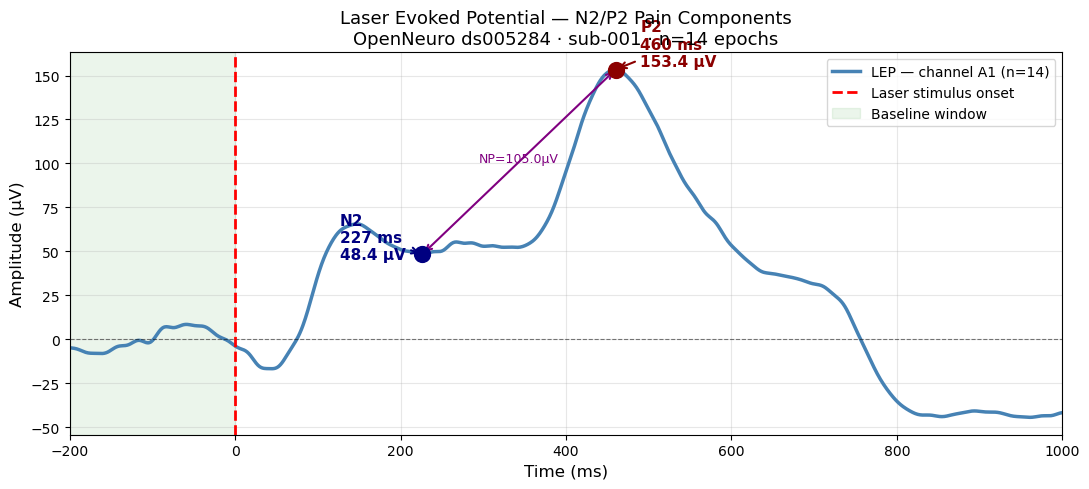

05_N2_P2_components.png saved


In [78]:
# SECTION 9B — PUBLICATION FIGURE WITH N2 AND P2

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(times_ms, signal_uv,
        color='steelblue', linewidth=2.5,
        label=f'LEP — channel {evoked.ch_names[ch_idx]} '
              f'(n={evoked.nave})')
ax.axhline(0, color='black', linewidth=0.8,
           linestyle='--', alpha=0.5)
ax.axvline(0, color='red', linewidth=2,
           linestyle='--', label='Laser stimulus onset')
ax.axvspan(-200, 0, alpha=0.08, color='green',
           label='Baseline window')

# N2
ax.scatter(n2_lat, n2_amp, color='navy', s=130, zorder=5)
ax.annotate(
    f'N2\n{n2_lat:.0f} ms\n{n2_amp:.1f} µV',
    xy=(n2_lat, n2_amp),
    xytext=(n2_lat - 100, n2_amp - 3),
    fontsize=11, color='navy', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='navy', lw=1.5)
)

# P2
ax.scatter(p2_lat, p2_amp, color='darkred', s=130, zorder=5)
ax.annotate(
    f'P2\n{p2_lat:.0f} ms\n{p2_amp:.1f} µV',
    xy=(p2_lat, p2_amp),
    xytext=(p2_lat + 30, p2_amp + 2),
    fontsize=11, color='darkred', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5)
)

# NP bracket
ax.annotate('',
    xy=(p2_lat, p2_amp), xytext=(n2_lat, n2_amp),
    arrowprops=dict(arrowstyle='<->', color='purple', lw=1.5))
ax.text((n2_lat+p2_lat)/2, (n2_amp+p2_amp)/2,
        f'NP={np_amplitude:.1f}µV',
        ha='center', fontsize=9, color='purple')

ax.set_xlabel("Time (ms)", fontsize=12)
ax.set_ylabel("Amplitude (µV)", fontsize=12)
ax.set_title(
    f"Laser Evoked Potential — N2/P2 Pain Components\n"
    f"OpenNeuro ds005284 · sub-001 · "
    f"n={evoked.nave} epochs",
    fontsize=13
)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-200, 1000)

plt.tight_layout()
plt.savefig(
    r"C:\Users\ssrko\Downloads\EEG-Pain-Project\05_N2_P2_components.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print("05_N2_P2_components.png saved")

In [77]:
# SECTION 10 — COMPLETE SUMMARY

print("=" * 55)
print("ANALYSIS COMPLETE — FULL SUMMARY")
print("=" * 55)
print(f"\nDATASET:")
print(f"  Source         : OpenNeuro ds005284")
print(f"  Subject        : sub-001")
print(f"  System         : BioSemi 64-channel EEG")
print(f"  Sampling rate  : {raw_filtered.info['sfreq']} Hz")
print(f"  Duration       : {raw_filtered.times[-1]:.1f} seconds")
print(f"\nPREPROCESSING:")
print(f"  Bad channels   : A2 (amplitude outlier)")
print(f"  Reference      : Average reference")
print(f"  Bandpass       : 1-40 Hz")
print(f"  Notch filter   : 50 Hz (mains noise)")
print(f"\nALPHA BAND ANALYSIS:")
print(f"  Peak alpha     : {peak_alpha_freq:.1f} Hz")
print(f"  Alpha power    : {alpha_power_uv2:.4f} µV²/Hz")
print(f"\nLASER EVOKED POTENTIAL:")
print(f"  Event ID       : 64 (laser stimulus)")
print(f"  Epochs used    : {evoked.nave}")
print(f"  N2 latency     : {n2_lat:.1f} ms")
print(f"  N2 amplitude   : {n2_amp:.2f} µV")
print(f"  P2 latency     : {p2_lat:.1f} ms")
print(f"  P2 amplitude   : {p2_amp:.2f} µV")
print(f"  NP amplitude   : {np_amplitude:.2f} µV")
print(f"\nOUTPUT FILES:")
for f in ['01_raw_psd.png','02_filtering_comparison.png',
          '03_alpha_band.png','04_LEP_waveform.png',
          '05_N2_P2_components.png']:
    print(f"  ✓ {f}")
print("=" * 55)
print("\nSCIENTIFIC SIGNIFICANCE:")
print("  This analysis demonstrates cortical processing of")
print("  nociceptive laser stimuli — the same pain pathway")
print("  investigated at spinal level in my MSc dissertation.")
print("  Peak alpha and LEP components are the core EEG")
print("  biomarkers measured by CNAP in chronic pain research.")
print("=" * 55)

ANALYSIS COMPLETE — FULL SUMMARY

DATASET:
  Source         : OpenNeuro ds005284
  Subject        : sub-001
  System         : BioSemi 64-channel EEG
  Sampling rate  : 1024.0 Hz
  Duration       : 328.0 seconds

PREPROCESSING:
  Bad channels   : A2 (amplitude outlier)
  Reference      : Average reference
  Bandpass       : 1-40 Hz
  Notch filter   : 50 Hz (mains noise)

ALPHA BAND ANALYSIS:
  Peak alpha     : 8.0 Hz
  Alpha power    : 1.4448 µV²/Hz

LASER EVOKED POTENTIAL:
  Event ID       : 64 (laser stimulus)
  Epochs used    : 14
  N2 latency     : 226.6 ms
  N2 amplitude   : 48.42 µV
  P2 latency     : 460.0 ms
  P2 amplitude   : 153.42 µV
  NP amplitude   : 105.00 µV

OUTPUT FILES:
  ✓ 01_raw_psd.png
  ✓ 02_filtering_comparison.png
  ✓ 03_alpha_band.png
  ✓ 04_LEP_waveform.png
  ✓ 05_N2_P2_components.png

SCIENTIFIC SIGNIFICANCE:
  This analysis demonstrates cortical processing of
  nociceptive laser stimuli — the same pain pathway
  investigated at spinal level in my MSc dissert

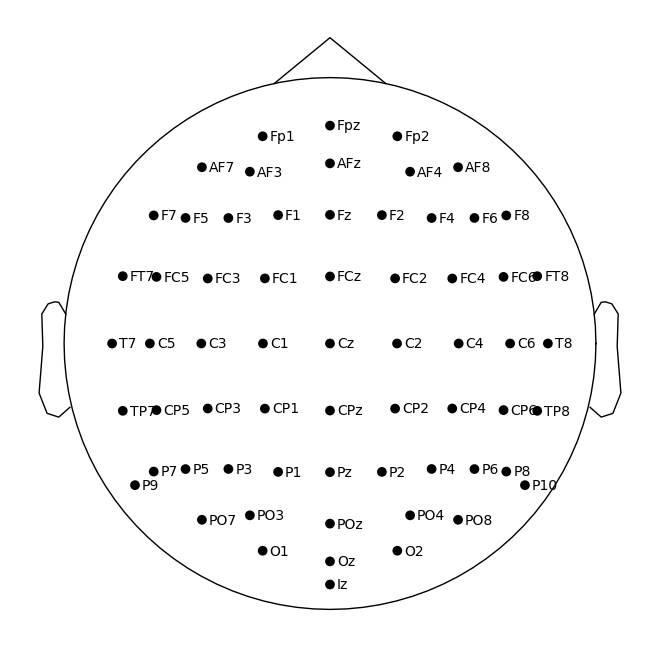

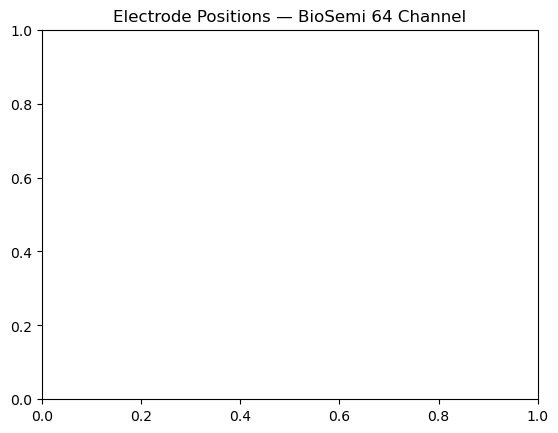

Montage set successfully


In [20]:
# Set standard BioSemi 64 electrode positions
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='ignore')

# Plot electrode positions on scalp map
montage.plot()
plt.title("Electrode Positions — BioSemi 64 Channel")
plt.show()

print("Montage set successfully")